In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
df=pd.read_csv('gurgaon_properties_cleaned2_v2.csv')

In [5]:
# df.drop(columns=[
#     'TV',
#     'Curtains',
#     'Water Purifier',
#     'Light',
#     'Chimney',
#     'Fridge',
#     'Sofa',
#     'Wardrobe',
#     'Dining Table',
#     'Stove',
#     'AC',
#     'Microwave',
#     'Bed',
#     'Washing Machine',
#     'Exhaust Fan',
#     'Fan',
#     'Geyser',
#     'Modular Kitchen'
# ], inplace=True)

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,gls avenue,sector 92,0.21,6953.0,302.00,Carpet area: 302 (28.06 sq.m.),1,1,1,0.0,South-East,Relatively New,NaN,NaN,302.0,0,0,0,0,0,0,63
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,0.0,NaN,Moderately old,NaN,5350.0,NaN,0,0,0,0,0,0,63
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,8.0,East,Moderately old,2588.0,1900.0,NaN,0,0,0,0,0,0,23
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,2.0,East,Old Property,NaN,4518.0,NaN,0,0,0,0,0,0,49
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,12.0,East,Relatively New,1457.0,NaN,849.0,0,0,0,0,0,0,152


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3750 entries, 0 to 3749
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3750 non-null   object 
 1   society              3749 non-null   object 
 2   sector               3750 non-null   object 
 3   price                3749 non-null   float64
 4   price_per_sqft       3749 non-null   float64
 5   area                 3749 non-null   float64
 6   areaWithType         3750 non-null   object 
 7   bedRoom              3750 non-null   int64  
 8   bathroom             3750 non-null   int64  
 9   balcony              3750 non-null   object 
 10  floorNum             3748 non-null   float64
 11  facing               2671 non-null   object 
 12  agePossession        3750 non-null   object 
 13  super_built_up_area  1883 non-null   float64
 14  built_up_area        1744 non-null   float64
 15  carpet_area          1901 non-null   f

# Price

<Axes: xlabel='price', ylabel='Count'>

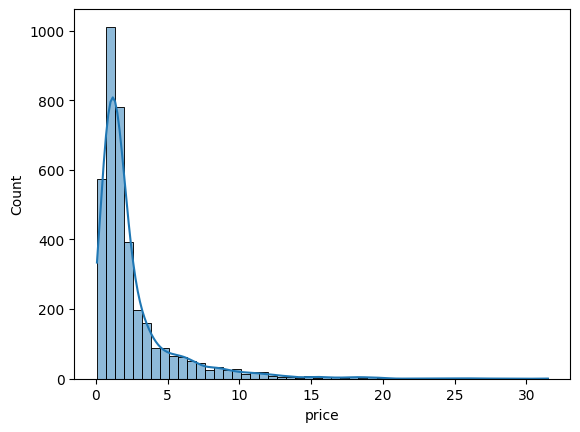

In [8]:
sns.histplot(df['price'],kde=True,bins=50)

<Axes: xlabel='price'>

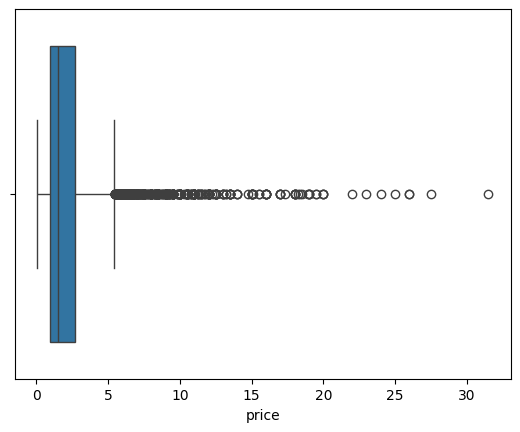

In [9]:
sns.boxplot(x=df['price'])

In [10]:
df['price'].describe()

count    3749.000000
mean        2.515444
std         2.967062
min         0.070000
25%         0.920000
50%         1.500000
75%         2.720000
max        31.500000
Name: price, dtype: float64

In [11]:
# outlier dataset
Q1=df['price'].describe()['25%']
Q3=df['price'].describe()['75%']
IQR=Q3-Q1
IQR

np.float64(1.8000000000000003)

In [12]:
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outlier_df=df[(df['price']<lower_bound) | (df['price']>upper_bound)]

In [13]:
outlier_df

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,0.0,NaN,Moderately old,NaN,5350.00,NaN,0,0,0,0,0,0,63
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,2.0,East,Old Property,NaN,4518.00,NaN,0,0,0,0,0,0,49
9,flat,.,sector 59,7.00,11000.0,6363.60,Super Built up area 6000(557.42 sq.m.),4,4,3+,6.0,South-West,Relatively New,6000.0,NaN,NaN,0,0,0,0,0,0,52
11,flat,pioneer araya,sector 62,9.14,19488.0,4690.10,Super Built up area 4690(435.72 sq.m.)Carpet a...,4,6,3,16.0,East,Relatively New,4690.0,NaN,3258.0,0,0,0,0,0,2,146
33,house,international city by sobha phase 1,sector 109,6.00,24691.0,2432.64,Plot area 270(225.75 sq.m.),4,5,3+,2.0,North,Relatively New,NaN,2430.00,NaN,0,1,0,0,0,2,96
39,house,independent,sector 26,13.50,29880.0,4520.84,Plot area 502(419.74 sq.m.),5,5,3+,2.0,North-East,Relatively New,NaN,4518.00,NaN,1,1,0,1,1,1,49
43,house,independent,sector 14,5.50,16975.0,3239.93,Plot area 360(301.01 sq.m.)Built Up area: 355 ...,5,4,2,2.0,East,Old Property,NaN,355.00,300.0,1,0,0,0,0,0,27
48,house,dlf city plots phase 2,sector 25,7.50,31686.0,1937.50,Plot area 215(179.77 sq.m.),9,9,3+,4.0,West,Relatively New,NaN,1935.00,NaN,1,1,0,1,0,2,160
67,house,emaar the palm springs,sector 54,14.00,62222.0,2249.66,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,NaN,2250.00,NaN,1,1,0,0,0,2,160
73,house,independent,sector 57,6.25,2778.0,27900.03,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.00,2500.0,0,1,0,0,0,2,61


In [14]:
outlier_df['price'].describe()

count    432.000000
mean       9.212593
std        4.062905
min        5.460000
25%        6.400000
50%        8.000000
75%       10.607500
max       31.500000
Name: price, dtype: float64

In [15]:
outlier_df.to_csv('outlierdf_price.csv', index=False, encoding='utf-8')

**Observation**
+ mostly outliers(right skweed data) 
  

# Price_per_sqft


In [16]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,gls avenue,sector 92,0.21,6953.0,302.00,Carpet area: 302 (28.06 sq.m.),1,1,1,0.0,South-East,Relatively New,NaN,NaN,302.0,0,0,0,0,0,0,63
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4,4,3+,0.0,NaN,Moderately old,NaN,5350.0,NaN,0,0,0,0,0,0,63
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3,3,3+,8.0,East,Moderately old,2588.0,1900.0,NaN,0,0,0,0,0,0,23
3,house,sector 15 part 2 rwa,sector 15,10.00,22222.0,4520.84,Plot area 502(419.74 sq.m.),5,5,2,2.0,East,Old Property,NaN,4518.0,NaN,0,0,0,0,0,0,49
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2,2,3+,12.0,East,Relatively New,1457.0,NaN,849.0,0,0,0,0,0,0,152


<Axes: xlabel='price_per_sqft', ylabel='Count'>

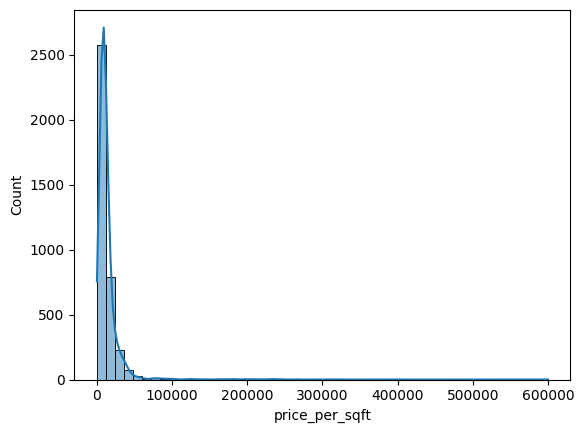

In [17]:
sns.histplot(df['price_per_sqft'],kde=True,bins=50)

<Axes: xlabel='price_per_sqft'>

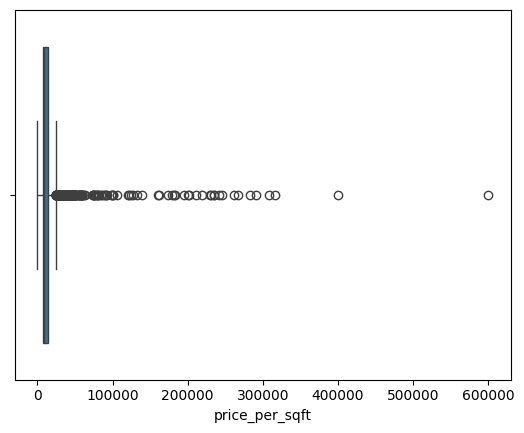

In [18]:
sns.boxplot(x=df['price_per_sqft'])

In [19]:
Q1=df['price_per_sqft'].describe()['25%']
Q3=df['price_per_sqft'].describe()['75%']
IQR=Q3-Q1
print(IQR)
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
outlier_df=df[(df['price_per_sqft']<lower_bound)|(df['price_per_sqft']>upper_bound)]

7056.0


In [20]:
outlier_df['price_per_sqft'].describe() 

count       366.000000
mean      53477.866120
std       60788.769243
min       24489.000000
25%       28270.250000
50%       33951.000000
75%       43174.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

In [21]:
outlier_df['property_type'].value_counts()

property_type
house    337
flat      29
Name: count, dtype: int64

In [22]:
outlier_df[outlier_df['area']<1000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
60,house,independent,sector 24,1.45,26852.0,538.19,Plot area 60(50.17 sq.m.),3,3,1,1.0,NaN,Old Property,NaN,540.0,NaN,0,0,0,0,0,0,9
149,house,independent,sector 43,2.10,38251.0,548.96,Plot area 61(51 sq.m.),10,10,3+,5.0,West,New Property,NaN,549.0,NaN,0,1,0,0,0,0,20
238,house,malibu towne,sector 47,1.15,41818.0,279.86,Plot area 275(25.55 sq.m.),3,3,3,2.0,North-East,Old Property,NaN,275.0,NaN,0,0,0,0,0,2,33
249,house,eros rosewood city,sector 49,1.60,31481.0,538.19,Plot area 60(50.17 sq.m.),4,4,3,4.0,East,New Property,NaN,540.0,NaN,0,0,0,0,0,2,27
259,house,independent,sector 4,0.58,86567.0,64.58,Plot area 67(6.22 sq.m.),2,2,1,2.0,West,Moderately old,NaN,67.0,NaN,0,0,0,1,1,0,7
286,house,independent,sector 51,2.25,25000.0,904.17,Plot area 100(83.61 sq.m.),6,3,3+,3.0,North-West,Relatively New,NaN,900.0,NaN,0,0,0,0,0,0,54
309,house,ardee city,sector 52,5.50,183333.0,301.39,Plot area 300(27.87 sq.m.),9,9,3+,3.0,South,Moderately old,NaN,300.0,NaN,0,1,0,1,1,2,26
334,house,independent,sector 13,0.50,90909.0,53.82,Plot area 55(5.11 sq.m.),12,4,3,4.0,NaN,Old Property,NaN,55.0,NaN,0,0,0,0,0,0,15
372,flat,lig flat,sector 40,1.50,50000.0,300.00,Built Up area: 300 (27.87 sq.m.),1,1,0,0.0,NaN,Undefined,NaN,300.0,NaN,0,0,0,0,0,0,0
398,house,dlf city plots,sector 26,4.00,40775.0,979.51,Plot area 109(91.14 sq.m.),4,3,2,2.0,NaN,Relatively New,NaN,981.0,NaN,0,0,0,0,0,2,0


In [23]:
outlier_df['area']=outlier_df['area'].apply(lambda x:x*9 if x<1000 else x )

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\3029074520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df['area']=outlier_df['area'].apply(lambda x:x*9 if x<1000 else x )


In [24]:
outlier_df['price_per_sqft'] = round((outlier_df['price']*10000000)/outlier_df['area'])

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\3769708580.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df['price_per_sqft'] = round((outlier_df['price']*10000000)/outlier_df['area'])


In [25]:
outlier_df['price_per_sqft'].describe() 
# old  Sstatistics:-->
# mean      52834.173228
# std       60291.318755
# min       24170.000000
# 25%       27778.000000
# 50%       33333.000000
# 75%       42222.000000
# max      600000.000000

count      366.000000
mean     28474.497268
std      12268.670754
min       2732.000000
25%      24951.750000
50%      29469.000000
75%      35191.500000
max      71889.000000
Name: price_per_sqft, dtype: float64

In [26]:
df.update(outlier_df)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

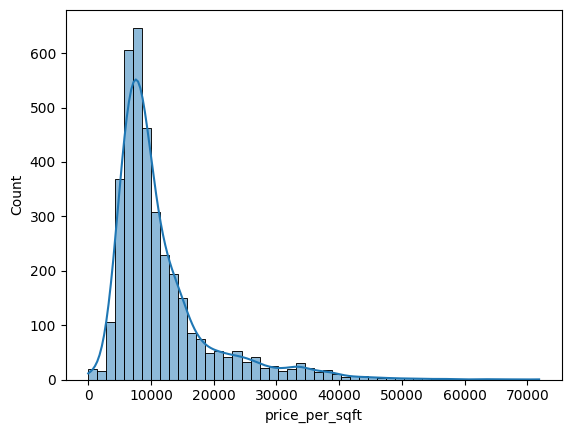

In [27]:
sns.histplot(df['price_per_sqft'],kde=True,bins=50)

<Axes: xlabel='price_per_sqft'>

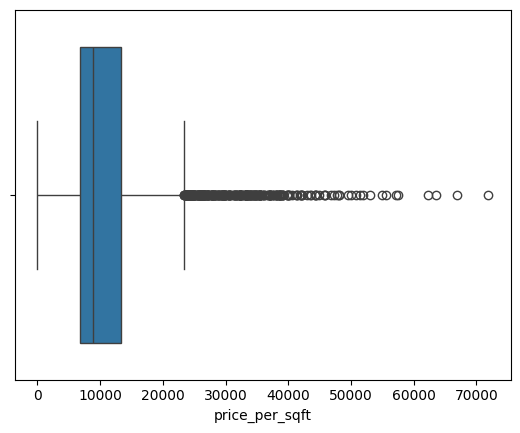

In [28]:
sns.boxplot(x=df['price_per_sqft'])

In [29]:
df[(df['price_per_sqft']>50000)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
67,house,emaar the palm springs,sector 54,14.00,62232.0,2249.66,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,NaN,2250.0,NaN,1,1,0,0,0,2,160
977,house,project housing board colony,sector 31,8.00,63523.0,1259.38,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,0,0
1047,flat,unitech vistas,sector 70,9.00,57508.0,1565.00,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,0,0
1876,house,malibu towne,sector 47,8.50,52998.0,1603.82,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,NaN,1600.0,NaN,0,0,0,0,0,2,99
2111,house,independent,sector 26,26.00,71889.0,3616.67,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,2,72
2290,house,dlf city plots,sector 26,26.00,57239.0,4542.37,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,4545.0,NaN,1,1,0,1,1,2,138
2410,house,independent,sector 26,14.75,51906.0,2841.67,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,2844.0,NaN,1,1,1,1,0,2,153
2566,house,cloudnine cottages,sector 48,5.50,54943.0,1001.04,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately old,NaN,1000.0,NaN,0,0,0,0,0,0,0
2894,house,nul,sector 28,12.50,51385.0,2432.64,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,2430.0,NaN,1,1,0,1,1,1,137
3069,house,emaar mgf marbella,sector 66,18.00,55557.0,3239.93,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately old,NaN,3240.0,NaN,1,1,0,1,0,1,75


In [30]:
df[(df['price_per_sqft']>50000)].shape

(12, 23)

In [31]:
df=df[df['price_per_sqft']<=50000]

In [32]:
df.shape

(3737, 23)

<Axes: xlabel='price_per_sqft'>

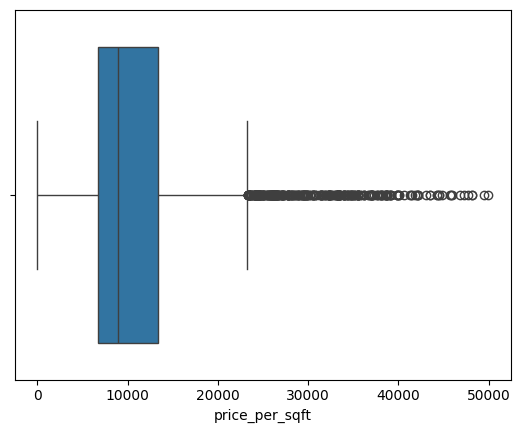

In [33]:
sns.boxplot(x=df['price_per_sqft'])

# Area

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\3835972997.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['area'],kde=True)


<Axes: ylabel='Density'>

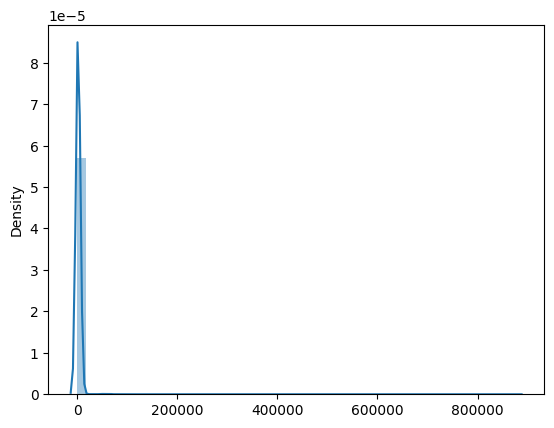

In [34]:
sns.distplot(x=df['area'],kde=True)

In [35]:
df['area'].describe()

count      3737.000000
mean       2822.021705
std       22609.652461
min         139.930000
25%        1250.000000
50%        1744.100000
75%        2335.770000
max      875000.000000
Name: area, dtype: float64

<Axes: xlabel='area'>

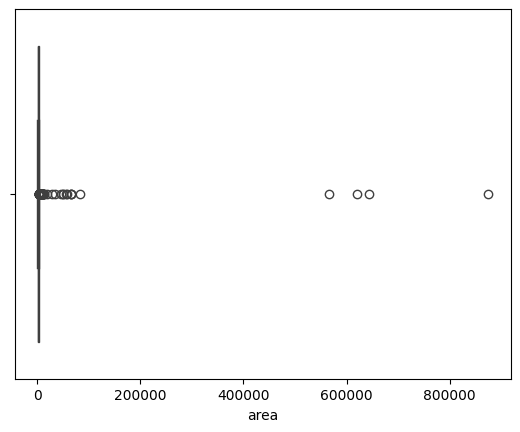

In [36]:
sns.boxplot(x=df['area'])

In [37]:
df[df['area']>100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
369,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,0,0,0,0,0,0,65
832,flat,signature the roselia,sector 95,0.45,7.0,642857.1,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76
1813,flat,hcbs sports ville,sector 48,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,1,44
1859,flat,signature global solera,sector 107,0.51,9.0,566666.7,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44


In [38]:
df = df[df['area'] < 100000]

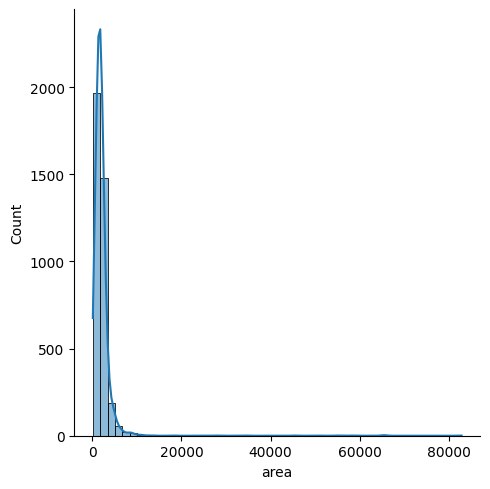

In [39]:
sns.displot(df['area'],kde=True,bins=50)

<Axes: xlabel='area'>

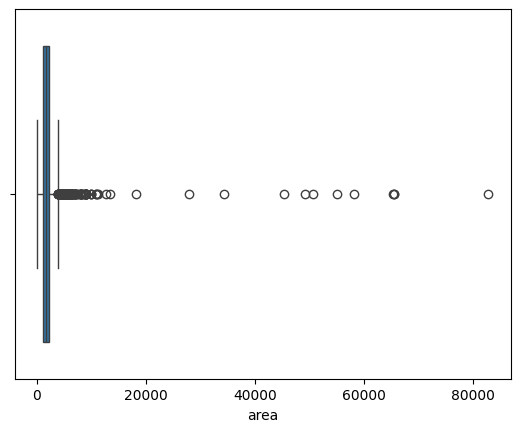

In [40]:
sns.boxplot(x=df['area'])

In [41]:
df[df['area']>10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
73,house,independent,sector 57,6.25,2778.00,27900.03,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,2,61
93,house,ganpati heights apartment,sector 13,1.25,151.00,82795.92,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
110,flat,rof ananda,sector 95,0.21,61.00,34426.20,Carpet area: 34401 (3195.96 sq.m.),1,1,1,13.0,North,Relatively New,NaN,NaN,34401.00,0,0,0,0,0,0,68
241,flat,signature the serenas,sector 48,0.28,57.00,49122.80,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,0,0,0,0,0,0,37
296,house,independent,sector 4,0.85,630.00,13497.93,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,NaN,13500.0,NaN,0,0,0,0,1,0,0
385,flat,mm golfestate,sector 65,13.20,12000.00,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately old,NaN,NaN,11000.00,0,0,0,0,0,0,60
616,flat,godrej icon,sector 88,1.75,1384.00,12644.50,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55
1098,flat,pyramid elite,sector 86,0.46,79.00,58227.80,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
2225,flat,ramsons kshitij,sector 95,0.24,53.00,45283.00,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,0,0,33
2487,house,independent,sector 51,5.50,1087.00,50579.57,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.0,North-East,Relatively New,NaN,8260.0,4860.00,0,0,0,1,0,2,49


In [42]:
# 3673,3375,2927,2225,1098,241,296,110 drop these rows bcz of data error 
df.drop(index=[3673,3375,2927,2225,1098,241,296,110],inplace=True)

In [43]:
df[df['area']>10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
93,house,ganpati heights apartment,sector 13,1.25,151.00,82795.92,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
2632,house,dlf city plot phase 4,sector 28,13.00,1992.00,65250.76,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
2487,house,independent,sector 51,5.50,1087.00,50579.57,Plot area 5620(4699.04 sq.m.)Built Up area: 82...,8,8,2,3.0,North-East,Relatively New,NaN,8260.0,4860.00,0,0,0,1,0,2,49
73,house,independent,sector 57,6.25,2778.00,27900.03,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,2,61
2672,flat,godrej air,sector 85,2.50,1379.00,18129.10,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Undefined,NaN,NaN,18122.00,0,0,0,0,0,2,44
616,flat,godrej icon,sector 88,1.75,1384.00,12644.50,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55
3374,house,independent,sector 43,27.50,24366.00,11291.33,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.0,NaN,1,1,0,1,1,2,42
385,flat,mm golfestate,sector 65,13.20,12000.00,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately old,NaN,NaN,11000.00,0,0,0,0,0,0,60
2696,house,independent,sector 50,5.00,4593.05,10886.00,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,2,0
3121,house,independent,sector 48,5.50,5093.00,10796.19,Plot area 1200(1003.35 sq.m.)Built Up area: 35...,3,3,3+,2.0,West,Moderately old,NaN,3500.0,NaN,1,1,0,1,1,0,49


In [44]:
df[df['area']>10000].index

Index([73, 93, 385, 616, 2487, 2632, 2672, 2696, 3121, 3374], dtype='int64')

In [45]:
df.loc[93, 'area'] = 115 * 9    # Ganpati Heights (from 7692.86 sq.m.)
df.loc[2632, 'area'] = 7250                 # Already given carpet area in sqft
df.loc[2487, 'area'] = 8260.0     # From 4699.04 sq.m.
df.loc[73, 'area'] = 2660       
df.loc[2672, 'area'] = 1812     
df.loc[2672, 'carpet_area'] = 1812     
df.loc[616, 'area'] = 1175.11                # Already sqft
df.loc[3374, 'area'] = 11286.0      # From 1048.5 sq.m.
df.loc[385, 'area'] = 11000                  # Already sqft
df.loc[2696, 'area'] = 1011.71 * 10.7639     # Suspicious row fixed properly
df.loc[2696, 'built_up_area'] = 1011.71 * 10.7639     # Suspicious row fixed properly
df.loc[3121, 'area'] = 3500.0

In [46]:
df[df['area']>10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
3374,house,independent,sector 43,27.5,24366.00,11286.000000,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.000000,NaN,1,1,0,1,1,2,42
385,flat,mm golfestate,sector 65,13.2,12000.00,11000.000000,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately old,NaN,NaN,11000.0,0,0,0,0,0,0,60
2696,house,independent,sector 50,5.0,4593.05,10889.945269,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,10889.945269,NaN,1,1,0,1,1,2,0


In [47]:
df['area']=round(df['area'],2)

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

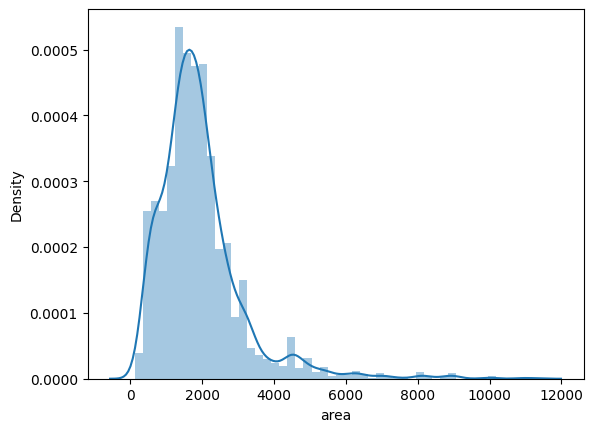

In [48]:
sns.distplot(df['area'])

In [49]:
df['area'].describe()

count     3725.000000
mean      1936.207742
std       1213.525117
min        139.930000
25%       1245.200000
50%       1741.200000
75%       2320.200000
max      11286.000000
Name: area, dtype: float64

<Axes: xlabel='area'>

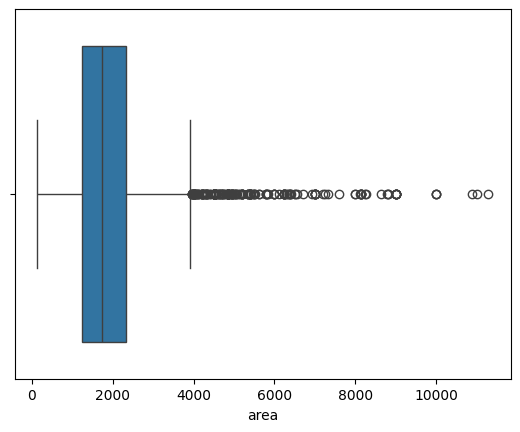

In [50]:
sns.boxplot(x=df['area'])

In [51]:
df['area'].describe()

count     3725.000000
mean      1936.207742
std       1213.525117
min        139.930000
25%       1245.200000
50%       1741.200000
75%       2320.200000
max      11286.000000
Name: area, dtype: float64

In [52]:
df['price'].describe()

count    3725.000000
mean        2.481450
std         2.859608
min         0.070000
25%         0.930000
50%         1.500000
75%         2.700000
max        31.500000
Name: price, dtype: float64

In [53]:
df['price_per_sqft'].describe()

count     3725.000000
mean     11449.517745
std       7476.912989
min        151.000000
25%       6757.000000
50%       8916.000000
75%      13343.000000
max      49968.000000
Name: price_per_sqft, dtype: float64

# BedRoom

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

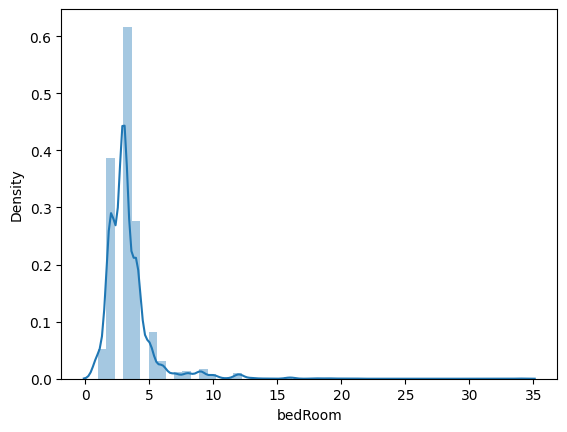

In [54]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

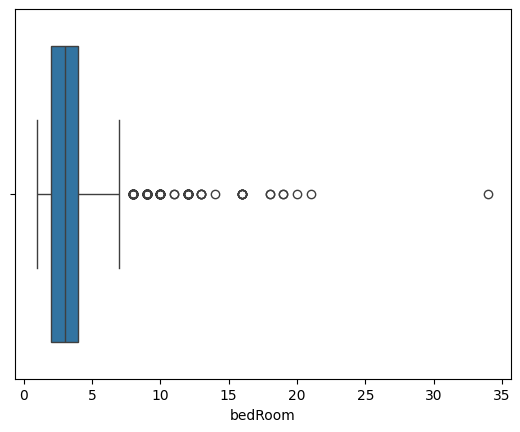

In [55]:
sns.boxplot(x=df['bedRoom'])

In [56]:
df[df['bedRoom']>10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
919,house,manohar nagar,sector 11,5.60,12444.0,4499.31,Plot area 500(418.06 sq.m.)Built Up area: 500 ...,34,34,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,0,0,0,0,2,0
154,house,independent,sector 54,5.00,43011.0,1162.50,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,1161.0,NaN,0,1,0,0,0,1,49
2698,house,independent,sector 43,4.50,39071.0,1151.74,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,1152.0,NaN,0,1,0,0,0,1,22
2777,house,independent,sector 17,3.87,5160.0,1625.35,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,68
1007,house,independent,sector 17,3.93,24214.0,1625.35,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,0,74
2714,house,private house,sector 55,7.05,46783.0,1506.95,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,1503.0,NaN,0,0,0,0,1,1,57
2201,house,independent,sector 54,5.50,38132.0,1442.36,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,1440.0,NaN,0,1,0,0,0,1,70
3034,house,dlf city plots,sector 26,20.00,44240.0,4520.84,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,4518.0,NaN,1,1,1,1,0,2,153
970,house,independent,sector 43,13.50,49968.0,2701.74,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,2700.0,NaN,1,1,0,1,1,0,41
2022,house,independent,sector 55,9.19,34015.0,2701.74,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,2700.0,NaN,0,1,0,1,0,2,49


In [57]:
df[df['bedRoom']>10].shape

(47, 23)

In [58]:
df=df[df['bedRoom']<=10]

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\1737319938.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

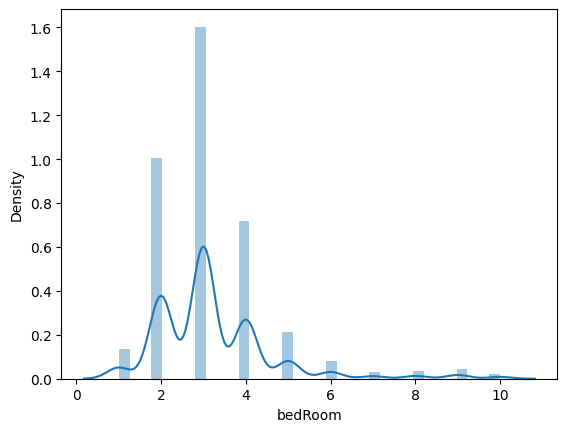

In [59]:
sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom'>

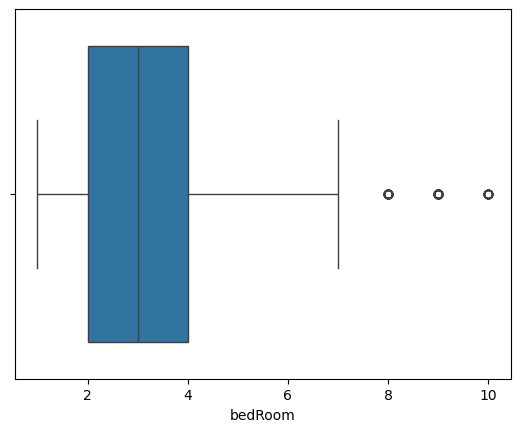

In [60]:
sns.boxplot(x=df['bedRoom'])

In [61]:
df['bedRoom'].describe()

count    3678.000000
mean        3.214519
std         1.410723
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

# Bathroom

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

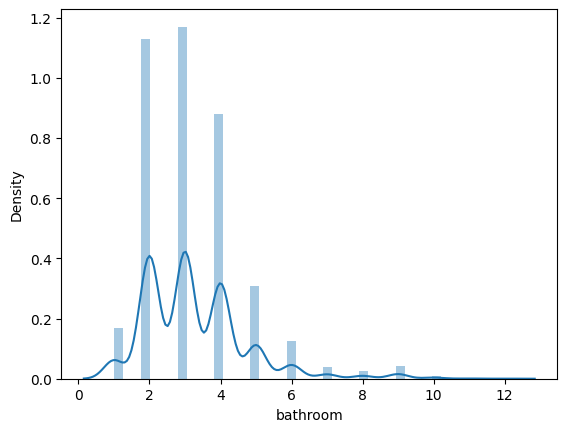

In [62]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

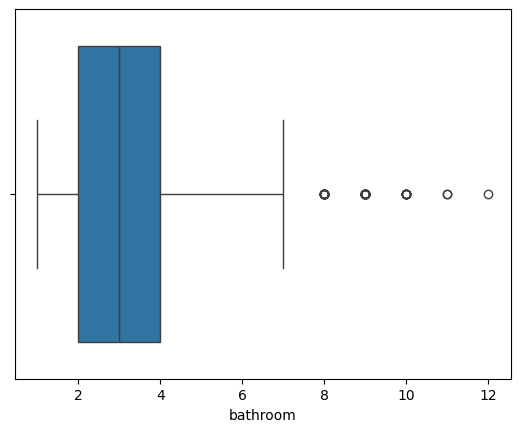

In [63]:
sns.boxplot(x=df['bathroom'])

In [64]:
df[df['bathroom']>10]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
222,house,independent,sector 39,7.00,10000.0,355.21,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,2,38
500,house,independent,sector 24,11.00,28868.0,3810.42,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,2,39
1441,house,adani brahma samsara,sector 60,18.02,28184.0,6393.76,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,2,146


In [65]:
df.loc[222,'area']=7000.0
df.loc[500,'area']=5000.0
df.loc[1441,'area']=6390.0

In [66]:
def fix_area(row):
    # print(row)
    if row['area']<max(row['built_up_area'],row['carpet_area']):
        return max(row['built_up_area'],row['carpet_area'])

In [67]:
mask=df.apply(lambda x:fix_area(x),axis=1)

In [68]:
mask=mask.dropna()

In [69]:
tempdf=df[[	'property_type','price'	,'price_per_sqft','area','areaWithType','bedRoom',	'bathroom','balcony','floorNum'	,'facing',	'agePossession'	,'super_built_up_area'	,'built_up_area','carpet_area']]

In [70]:
tempdf=tempdf.loc[mask.index]
tempdf.insert(loc=4,column='mask_area',value=mask)

In [71]:
tempdf

,property_type,price,price_per_sqft,area,mask_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area
6,flat,1.30,6510.0,1996.90,1997.00,Built Up area: 1997 (185.53 sq.m.),3,3,0,16.0,NaN,Undefined,NaN,1997.00,NaN
15,flat,3.20,10159.0,3149.90,3150.00,Built Up area: 3150 (292.64 sq.m.)Carpet area:...,4,3,2,1.0,NaN,Relatively New,NaN,3150.00,1750.00
17,flat,1.93,8075.0,2390.10,2400.00,Super Built up area 2408(223.71 sq.m.)Built Up...,3,4,3,7.0,North-East,Relatively New,2408.0,2400.00,2390.00
38,house,0.75,20833.0,355.21,360.00,Plot area 40(33.45 sq.m.),7,4,3+,4.0,NaN,Moderately old,NaN,360.00,NaN
54,flat,3.21,16050.0,2000.00,2140.00,Super Built up area 2185(202.99 sq.m.)Built Up...,3,4,3+,15.0,North-East,Relatively New,2185.0,2140.00,2000.00
69,house,0.75,10067.0,742.71,745.00,Plot area 745(69.21 sq.m.)Built Up area: 745 s...,2,2,2,11.0,North-East,New Property,NaN,745.00,NaN
88,house,2.00,14815.0,1345.49,1350.00,Built Up area: 1350 (125.42 sq.m.),5,5,2,3.0,East,Undefined,NaN,1350.00,NaN
89,flat,2.10,12173.0,1725.10,1745.00,Super Built up area 2175(202.06 sq.m.)Built Up...,4,4,3,0.0,East,New Property,2175.0,1745.00,1725.00
98,house,4.00,22222.0,1797.57,4800.00,Plot area 1800(167.23 sq.m.)Built Up area: 480...,9,9,3+,2.0,East,Relatively New,NaN,4800.00,3800.00
100,flat,1.80,9474.0,1899.90,1900.00,Built Up area: 1900 (176.52 sq.m.),3,4,0,9.0,NaN,Undefined,NaN,1900.00,NaN


In [72]:
tempdf.shape

(510, 15)

In [73]:
def area_diffrence(row):
    if row['mask_area']-row['area']>=100:
        return row['mask_area']

In [74]:
mask2=tempdf.apply(area_diffrence,axis=1)

In [75]:
mask2.dropna(inplace=True)

In [76]:
mask2.shape

(145,)

In [77]:
tempdf.loc[mask2.index]

,property_type,price,price_per_sqft,area,mask_area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area
54,flat,3.21,16050.0,2000.00,2140.00,Super Built up area 2185(202.99 sq.m.)Built Up...,3,4,3+,15.0,North-East,Relatively New,2185.0,2140.00,2000.00
98,house,4.00,22222.0,1797.57,4800.00,Plot area 1800(167.23 sq.m.)Built Up area: 480...,9,9,3+,2.0,East,Relatively New,NaN,4800.00,3800.00
112,house,0.58,10591.0,548.96,1000.00,Plot area 550(51.1 sq.m.)Built Up area: 1000 s...,2,3,2,2.0,South-East,Relatively New,NaN,1000.00,900.00
194,flat,2.78,11346.0,2450.20,2599.00,Super Built up area 2690(249.91 sq.m.)Built Up...,3,3,3,3.0,North,New Property,2690.0,2599.00,2450.00
212,house,8.00,9654.0,365.97,8286.00,Plot area 362(33.63 sq.m.)Built Up area: 8286 ...,10,10,3+,4.0,NaN,Relatively New,NaN,8286.00,NaN
220,house,5.50,2716.0,1937.50,2850.00,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately old,NaN,2850.00,2250.00
242,flat,2.33,14463.0,1611.00,1711.00,Built Up area: 1711 (158.96 sq.m.)Carpet area:...,3,3,3,17.0,North-East,Relatively New,NaN,1711.00,1611.00
254,flat,1.50,12500.0,1200.00,1300.00,Super Built up area 1400(130.06 sq.m.)Built Up...,2,2,3,17.0,North-East,Relatively New,1400.0,1300.00,1200.00
274,flat,1.50,9740.0,1540.00,1780.00,Super Built up area 1929(179.21 sq.m.)Built Up...,3,3,3+,18.0,West,Relatively New,1929.0,1780.00,1540.00
280,flat,1.55,13790.0,1124.00,1300.00,Super Built up area 1406(130.62 sq.m.)Built Up...,2,2,3+,18.0,South,Relatively New,1406.0,1300.00,1124.00


In [78]:
df.loc[mask2.index,'area']=mask2

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\2026402244.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['area'])


<Axes: ylabel='Density'>

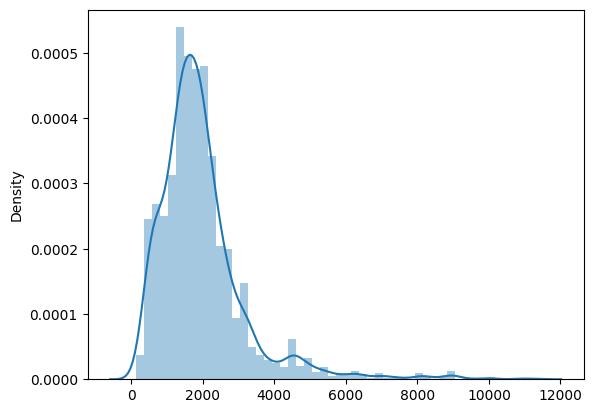

In [79]:
sns.distplot(x=df['area'])

In [80]:
df['area'].describe()

count     3678.000000
mean      1961.797308
std       1256.059831
min        139.930000
25%       1259.510000
50%       1746.400000
75%       2335.770000
max      11286.000000
Name: area, dtype: float64

<Axes: xlabel='area'>

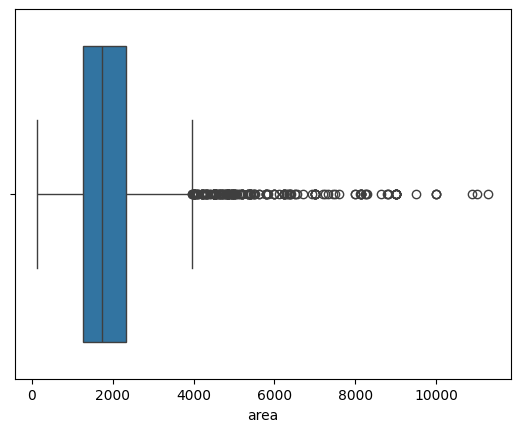

In [81]:
sns.boxplot(x=df['area'])

In [82]:
df[df['area']>10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
385,flat,mm golfestate,sector 65,13.2,12000.00,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately old,NaN,NaN,11000.0,0,0,0,0,0,0,60
2696,house,independent,sector 50,5.0,4593.05,10889.95,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,10889.945269,NaN,1,1,0,1,1,2,0
3374,house,independent,sector 43,27.5,24366.00,11286.00,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.000000,NaN,1,1,0,1,1,2,42


In [83]:
df.shape

(3678, 23)

# Super built up area

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\2423862405.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['super_built_up_area'])


<Axes: ylabel='Density'>

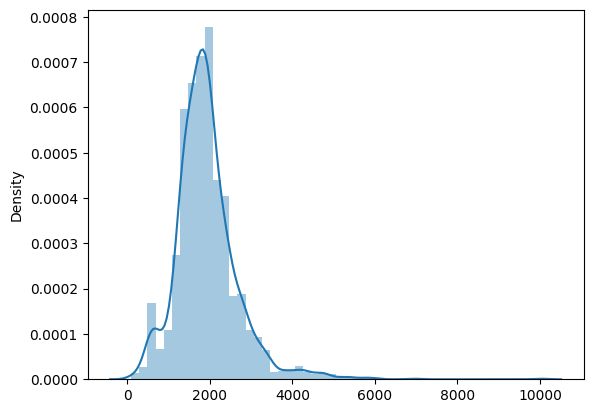

In [84]:
sns.distplot(x=df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

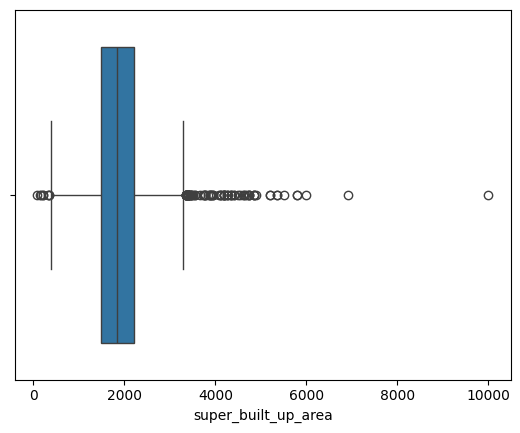

In [85]:
sns.boxplot(x=df['super_built_up_area'])

In [86]:
df['super_built_up_area'].describe()

count     1883.000000
mean      1925.281166
std        764.622030
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [87]:
df[df['super_built_up_area']>6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
2350,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,0,0,0,0,2,140
3406,flat,krrish provence estate,sector 59,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,0,0,0,0,0,49


# built up area

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

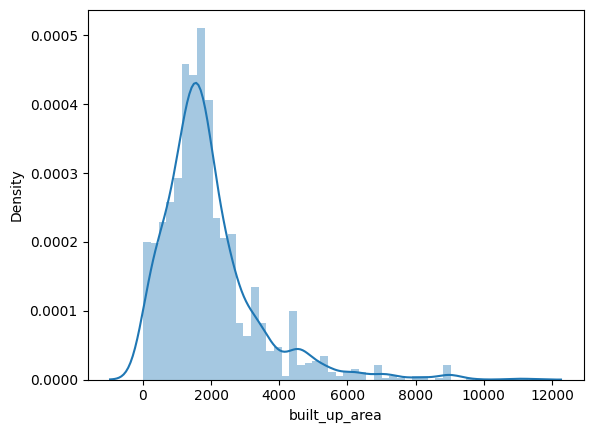

In [88]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

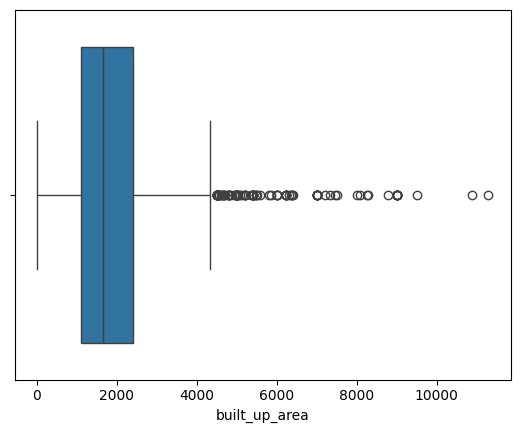

In [89]:
sns.boxplot(x=df['built_up_area'])

In [90]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
2696,house,independent,sector 50,5.0,4593.05,10889.95,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,10889.945269,NaN,1,1,0,1,1,2,0
3374,house,independent,sector 43,27.5,24366.00,11286.00,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,11286.000000,NaN,1,1,0,1,1,2,42


# carpet area

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

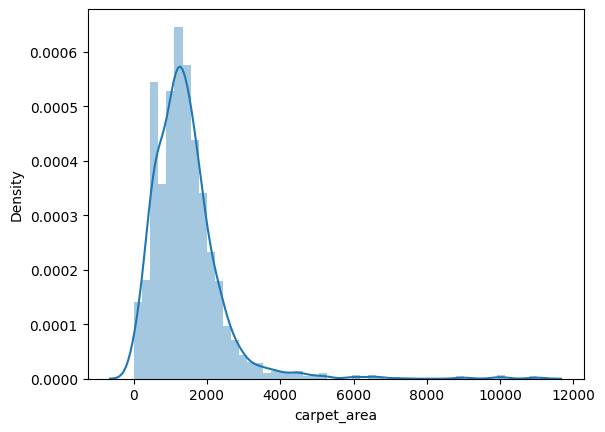

In [91]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

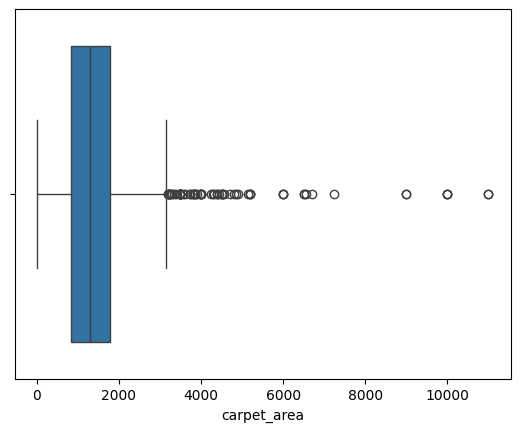

In [92]:
sns.boxplot(x=df['carpet_area'])

In [93]:
df[df['carpet_area']>8000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
385,flat,mm golfestate,sector 65,13.20,12000.0,11000.00,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately old,NaN,NaN,11000.0,0,0,0,0,0,0,60
1150,flat,the penthouses at the hibiscus,sector 50,8.50,8500.0,10000.00,Carpet area: 10000 (929.03 sq.m.),4,4,3,9.0,South-East,Moderately old,NaN,NaN,10000.0,0,0,0,0,0,0,35
2128,flat,the penthouses at the hibiscus,sector 50,8.00,8888.0,9000.90,Carpet area: 9000 (836.13 sq.m.),4,3,3,7.0,South-East,Moderately old,NaN,NaN,9000.0,0,0,0,0,0,0,35
2164,house,independent,sector 26,18.40,1859.0,4520.84,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,1,0,2,60
2455,house,independent,sector 25,8.00,8000.0,9999.66,Carpet area: 10000 (929.03 sq.m.),3,9,2,3.0,NaN,New Property,NaN,NaN,10000.0,0,0,0,0,0,0,0
2979,house,independent,sector 26,18.25,18250.0,548.96,Plot area 550(51.1 sq.m.)Carpet area: 10000 sq...,7,9,3+,4.0,East,Relatively New,NaN,NaN,10000.0,1,1,1,1,0,2,77
3089,house,independent,sector 25,10.00,37013.0,9500.00,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3+,3.0,East,Moderately old,NaN,9500.0,9000.0,0,1,0,1,0,1,29


In [94]:
df.loc[2455,'area']=10000
df.loc[2164,'area']=11000
df.loc[2979,'area']=10000

<Axes: xlabel='carpet_area'>

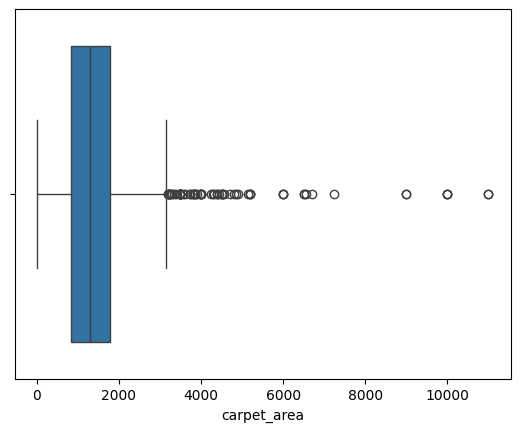

In [95]:
sns.boxplot(x=df['carpet_area'])

In [96]:
df[df['carpet_area']>8000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
385,flat,mm golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately old,NaN,NaN,11000.0,0,0,0,0,0,0,60
1150,flat,the penthouses at the hibiscus,sector 50,8.50,8500.0,10000.0,Carpet area: 10000 (929.03 sq.m.),4,4,3,9.0,South-East,Moderately old,NaN,NaN,10000.0,0,0,0,0,0,0,35
2128,flat,the penthouses at the hibiscus,sector 50,8.00,8888.0,9000.9,Carpet area: 9000 (836.13 sq.m.),4,3,3,7.0,South-East,Moderately old,NaN,NaN,9000.0,0,0,0,0,0,0,35
2164,house,independent,sector 26,18.40,1859.0,11000.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.0,0,1,1,1,0,2,60
2455,house,independent,sector 25,8.00,8000.0,10000.0,Carpet area: 10000 (929.03 sq.m.),3,9,2,3.0,NaN,New Property,NaN,NaN,10000.0,0,0,0,0,0,0,0
2979,house,independent,sector 26,18.25,18250.0,10000.0,Plot area 550(51.1 sq.m.)Carpet area: 10000 sq...,7,9,3+,4.0,East,Relatively New,NaN,NaN,10000.0,1,1,1,1,0,2,77
3089,house,independent,sector 25,10.00,37013.0,9500.0,Plot area 2700(250.84 sq.m.)Built Up area: 950...,5,5,3+,3.0,East,Moderately old,NaN,9500.0,9000.0,0,1,0,1,0,1,29


# luxury_score

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

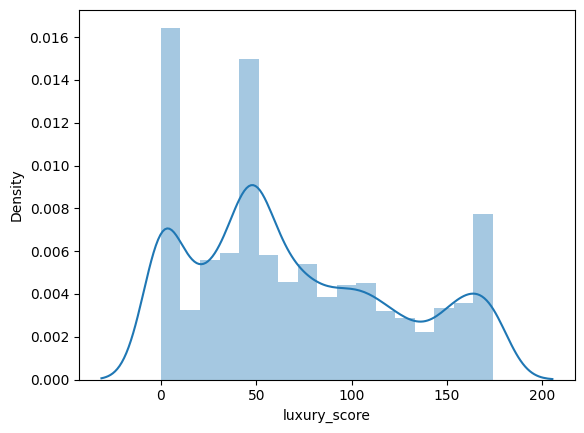

In [97]:
sns.distplot(df['luxury_score'])

<Axes: xlabel='luxury_score'>

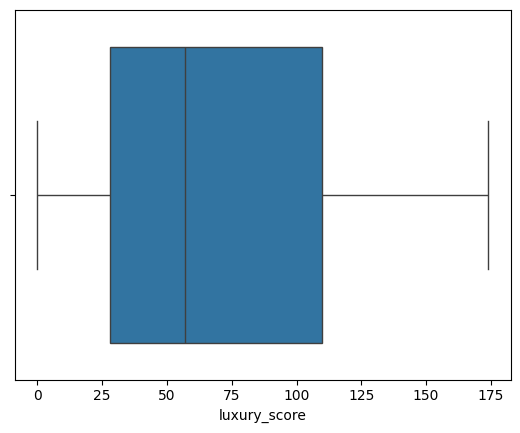

In [98]:
sns.boxplot(x=df['luxury_score'])

In [99]:
df.shape

(3678, 23)

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

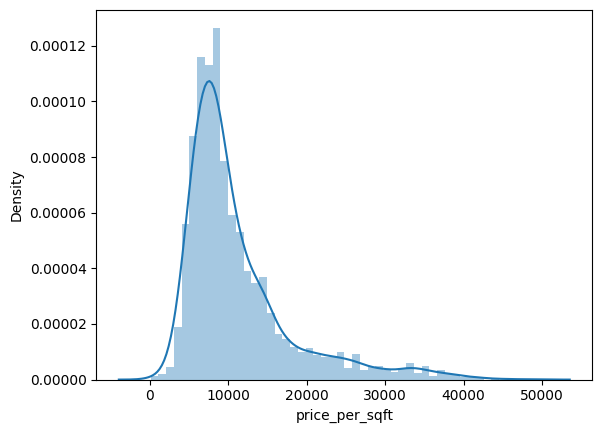

In [100]:
sns.distplot(df['price_per_sqft'])

In [101]:
df['price_per_sqft'].describe()

count     3678.000000
mean     11189.309027
std       6986.807545
min        151.000000
25%       6735.000000
50%       8886.000000
75%      13133.500000
max      49448.000000
Name: price_per_sqft, dtype: float64

In [102]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [103]:
df['price_per_sqft'].describe()

count     3678.000000
mean     11113.366775
std       6911.596129
min        544.000000
25%       6720.500000
50%       8848.000000
75%      12906.500000
max      49448.000000
Name: price_per_sqft, dtype: float64

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

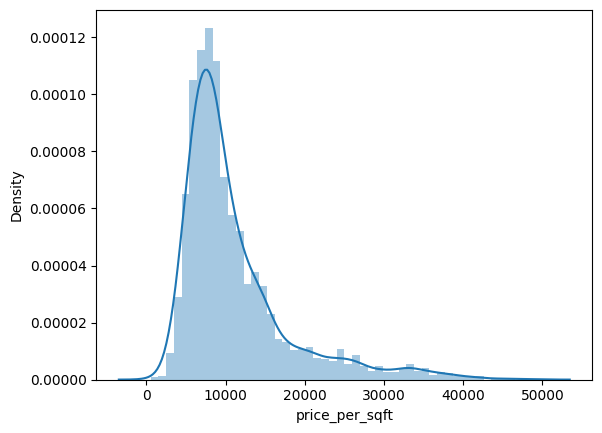

In [104]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

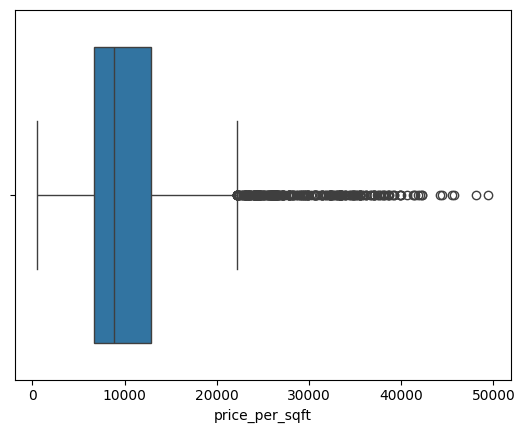

In [105]:
sns.boxplot(x=df['price_per_sqft'])

In [106]:
df[df['price_per_sqft']>40000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
440,house,unitech escape,sector 50,10.80,41461.0,2604.86,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,2,103
785,house,independent,sector 55,5.00,44240.0,1130.21,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,2,44
1031,house,independent,sector 50,12.50,40604.0,3078.48,Plot area 342(285.96 sq.m.),6,5,3,4.0,East,Moderately old,NaN,3078.0,NaN,1,1,0,1,0,2,23
1476,house,independent,sector 25,13.00,45748.0,2841.67,Plot area 316(264.22 sq.m.),6,8,3+,1.0,NaN,Relatively New,NaN,2844.0,NaN,1,1,1,1,0,1,0
1518,flat,dlf the grove,sector 54,5.70,41245.0,1382.00,Built Up area: 1382 (128.39 sq.m.),3,3,3,1.0,East,Undefined,NaN,1382.0,NaN,0,0,0,0,0,0,46
1760,house,independent,sector 26,18.90,41806.0,4520.84,Plot area 502(419.74 sq.m.),6,8,2,3.0,North-East,Relatively New,NaN,4518.0,NaN,1,1,1,1,0,2,120
1769,house,independent,sector 28,11.75,41349.0,2841.67,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,2844.0,NaN,1,1,1,0,0,2,54
2228,house,independent,sector 26,20.00,44451.0,4499.31,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,4500.0,NaN,0,1,0,1,0,1,97
2354,house,sushant lok 1 builder floors,sector 43,2.45,45523.0,538.19,Plot area 60(50.17 sq.m.)Built Up area: 540 sq...,4,4,3+,3.0,West,Moderately old,NaN,540.0,351.0,1,1,0,1,1,1,123
2532,house,independent,sector 26,19.00,42229.0,4499.31,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately old,NaN,4500.0,NaN,1,1,1,1,0,2,103


In [107]:
x=df[df['price_per_sqft']<=20000]
(x['area']/x['bedRoom']).quantile(0.05)
# 2% of houses have area/bedroom smaller than this value
# These are extreme small-space outliers
# vaule come 180.295 which means lowest 5 % pproperty has per room size is 180 sqft which is very low


np.float64(247.57)

In [108]:
df[(df['area']/df['bedRoom'])<247]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
38,house,independent,sector 28,0.75,21114.0,355.21,Plot area 40(33.45 sq.m.),7,4,3+,4.0,NaN,Moderately old,NaN,360.00,NaN,0,0,0,0,0,0,7
48,house,dlf city plots phase 2,sector 25,7.50,38710.0,1937.50,Plot area 215(179.77 sq.m.),9,9,3+,4.0,West,Relatively New,NaN,1935.00,NaN,1,1,0,1,0,2,160
56,flat,pivotal devaan,sector 84,0.34,7039.0,483.00,Carpet area: 483 (44.87 sq.m.),2,2,1,1.0,East,Relatively New,NaN,NaN,483.00,0,0,0,0,0,2,84
93,house,ganpati heights apartment,sector 13,1.25,12077.0,1035.00,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.00,NaN,0,0,0,0,1,0,7
114,house,dlf city plots phase 2,sector 25,6.50,33548.0,1937.50,Plot area 215(179.77 sq.m.),9,9,3+,3.0,West,Old Property,NaN,1935.00,NaN,1,1,1,1,0,2,142
115,flat,pivotal devaan,sector 84,0.36,7589.0,474.40,Super Built up area 583(54.16 sq.m.)Carpet are...,2,2,1,9.0,West,Relatively New,583.0,NaN,481.00,0,0,0,0,0,1,80
146,house,independent,sector 1,0.80,6696.0,1194.79,Plot area 1200(111.48 sq.m.),8,8,2,1.0,NaN,Relatively New,NaN,1200.00,NaN,0,0,0,0,0,0,0
165,house,independent,sector 9,0.42,9290.0,452.08,Built Up area: 450 (41.81 sq.m.),5,3,2,2.0,NaN,Undefined,NaN,450.00,NaN,0,0,0,0,0,0,0
186,house,independent,sector 7,0.45,8040.0,559.72,Plot area 562(52.21 sq.m.),3,2,1,1.0,North-East,Old Property,NaN,562.00,NaN,0,0,0,0,0,0,15
202,house,rattan vihar rajendra park,sector 106,0.85,14101.0,602.78,Plot area 600(55.74 sq.m.),5,5,3+,4.0,NaN,New Property,NaN,600.00,NaN,0,0,0,0,0,0,0


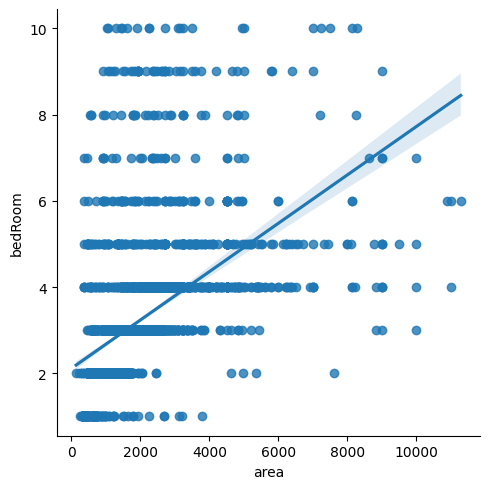

In [109]:
sns.lmplot(data=df,x='area',y='bedRoom')

In [111]:
df[df['area']/df['bedRoom']<100]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
38,house,independent,sector 28,0.75,21114.0,355.21,Plot area 40(33.45 sq.m.),7,4,3+,4.0,NaN,Moderately old,NaN,360.0,NaN,0,0,0,0,0,0,7
165,house,independent,sector 9,0.42,9290.0,452.08,Built Up area: 450 (41.81 sq.m.),5,3,2,2.0,NaN,Undefined,NaN,450.0,NaN,0,0,0,0,0,0,0
277,house,sector 38 rwa,sector 38,1.40,24086.0,581.25,Plot area 65(54.35 sq.m.)Built Up area: 62 sq....,8,8,3,4.0,East,Moderately old,NaN,62.0,60.0,0,0,0,0,1,2,40
314,house,jacobpura,sector 12,0.53,14921.0,355.21,Plot area 360(33.45 sq.m.),4,4,2,3.0,East,Relatively New,NaN,360.0,NaN,0,0,0,0,0,0,0
1075,house,independent,sector 17,0.32,22869.0,139.93,Built Up area: 145 (13.47 sq.m.),2,2,0,3.0,NaN,Undefined,NaN,145.0,NaN,0,0,0,0,0,0,0
1432,house,ss omnia,sector 86,0.42,8671.0,484.38,Plot area 50(4.65 sq.m.),5,3,2,3.0,NaN,Relatively New,NaN,50.0,NaN,0,0,0,0,0,0,0
1542,house,independent,sector 3,0.50,11060.0,452.08,Plot area 450(41.81 sq.m.),5,3,3,3.0,NaN,Moderately old,NaN,450.0,NaN,0,0,0,0,0,0,0
1639,house,ashok vihar phase iii extension,sector 3,0.40,8848.0,452.08,Plot area 50(41.81 sq.m.),7,4,3+,4.0,NaN,New Property,NaN,450.0,NaN,0,0,0,1,0,0,7
1715,house,rattan garden,sector 7,0.83,17525.0,473.61,Carpet area: 472 (43.85 sq.m.),5,3,2,3.0,East,Undefined,NaN,NaN,472.0,0,0,0,0,0,0,0
1925,house,rajendra park gurgaon,sector 105,0.37,10416.0,355.21,Plot area 360(33.45 sq.m.),4,3,2,3.0,East,Relatively New,NaN,360.0,NaN,0,0,0,0,0,0,0


In [112]:
df[df['area']/df['bedRoom']<100].shape

(22, 23)

In [114]:
df=df[df['area']/df['bedRoom']>100]

In [118]:
outlier_df=df[(df['area']/df['bedRoom']<247) & (df['bedRoom']>3)]

In [119]:
outlier_df['bedRoom']=round(outlier_df['bedRoom']/outlier_df['floorNum'])

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\3823887811.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outlier_df['bedRoom']=round(outlier_df['bedRoom']/outlier_df['floorNum'])


In [120]:
df.update(outlier_df)

C:\Users\sarth\anaconda3\Lib\site-packages\pandas\core\dtypes\cast.py:377: RuntimeWarning: invalid value encountered in cast
  new_result = trans(result).astype(dtype)
C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\1617301329.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[1. 4. 3. ... 3. 3. 3.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.update(outlier_df)


In [121]:
df['area_room_ratio']=df['area']/df['bedRoom']

C:\Users\sarth\AppData\Local\Temp\ipykernel_13236\2419531321.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['area_room_ratio']=df['area']/df['bedRoom']


In [123]:
df[(df['area_room_ratio']<247) & (df['bedRoom']>4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
146,house,independent,sector 1,0.80,6696.0,1194.79,Plot area 1200(111.48 sq.m.),8.0,8,2,1.0,NaN,Relatively New,NaN,1200.0,NaN,0,0,0,0,0,0,0,149.348750
395,house,independent,sector 7,1.16,11714.0,990.28,Carpet area: 110 (91.97 sq.m.),5.0,4,2,1.0,North-East,Undefined,NaN,NaN,110.0,0,0,0,0,0,0,0,198.056000
486,house,independent,sector 17,0.32,5717.0,559.72,Built Up area: 565 (52.49 sq.m.),5.0,1,0,1.0,NaN,Undefined,NaN,565.0,NaN,0,0,0,0,0,0,0,111.944000
640,house,independent,sector 11,3.50,15558.0,2249.66,Built Up area: 2250 (209.03 sq.m.),10.0,1,0,1.0,NaN,New Property,NaN,2250.0,NaN,0,0,0,0,0,0,0,224.966000
904,house,"bhim nagar, sector 6",sector 6,0.85,14624.0,581.22,Plot area 67(6.22 sq.m.),5.0,2,2,1.0,NaN,Old Property,NaN,67.0,NaN,0,0,0,1,0,0,29,116.244000
1224,house,shivpuri,sector 7,2.80,12446.0,2249.66,Plot area 2250(209.03 sq.m.),10.0,7,3,1.0,NaN,Old Property,NaN,2250.0,NaN,1,1,0,1,1,2,0,224.966000
1690,house,independent,sector 105,1.10,12166.0,904.17,Carpet area: 900 (83.61 sq.m.),6.0,4,1,1.0,South-West,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,150.695000
1836,house,independent,sector 5,1.65,8516.0,1937.52,Built Up area: 220 (20.44 sq.m.),9.0,9,0,1.0,NaN,New Property,NaN,220.0,NaN,0,0,0,0,0,0,0,215.280000
2275,house,independent,sector 3,1.10,10019.0,1097.92,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5.0,4,2,1.0,East,Undefined,NaN,1100.0,900.0,0,0,0,0,0,0,0,219.584000
2538,house,independent,sector 12,2.50,13908.0,1797.57,Plot area 1800(167.23 sq.m.),9.0,5,2,1.0,South-East,Old Property,NaN,1800.0,NaN,0,0,0,1,0,0,8,199.730000


In [124]:
df=df[~((df['area_room_ratio']<247) & (df['bedRoom']>4))]

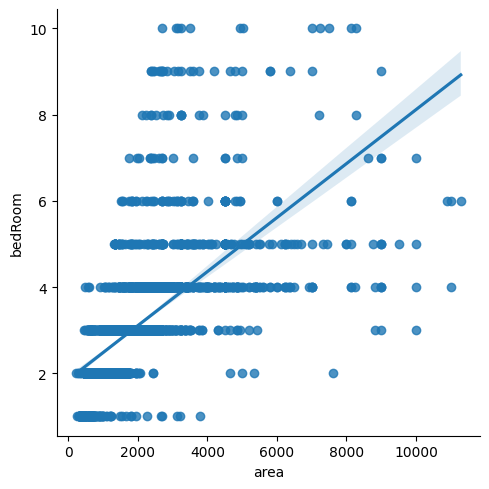

In [125]:
sns.lmplot(df,x='area',y='bedRoom')

In [126]:
df.shape

(3641, 24)

In [127]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,gls avenue,sector 92,0.21,6954.0,302.00,Carpet area: 302 (28.06 sq.m.),1.0,1,1,0.0,South-East,Relatively New,NaN,NaN,302.0,0,0,0,0,0,0,63,302.000
1,flat,paras quartier,sector 59,5.90,11028.0,5350.00,Built Up area: 5350 (497.03 sq.m.),4.0,4,3+,0.0,NaN,Moderately old,NaN,5350.0,NaN,0,0,0,0,0,0,63,1337.500
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,2588.40,Super Built up area 2588(240.43 sq.m.)Built Up...,3.0,3,3+,8.0,East,Moderately old,2588.0,1900.0,NaN,0,0,0,0,0,0,23,862.800
3,house,sector 15 part 2 rwa,sector 15,10.00,22120.0,4520.84,Plot area 502(419.74 sq.m.),5.0,5,2,2.0,East,Old Property,NaN,4518.0,NaN,0,0,0,0,0,0,49,904.168
4,flat,eldeco accolade,sector 48,0.72,4975.0,1447.20,Super Built up area 1457(135.36 sq.m.)Carpet a...,2.0,2,3+,12.0,East,Relatively New,1457.0,NaN,849.0,0,0,0,0,0,0,152,723.600


In [128]:
df.to_csv('gurgaon_properties_outlier_treated.csv',index=False)